In [15]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving archive (1) (1).zip to archive (1) (1) (1).zip
Dataset loaded successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [16]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [17]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [18]:
print("\nClass Distribution:")
display(df['Class'].value_counts())
display(df['Class'].value_counts(normalize=True) * 100)


Class Distribution:


,count
Class,
0,284315
1,492


,proportion
Class,
0,99.827251
1,0.172749


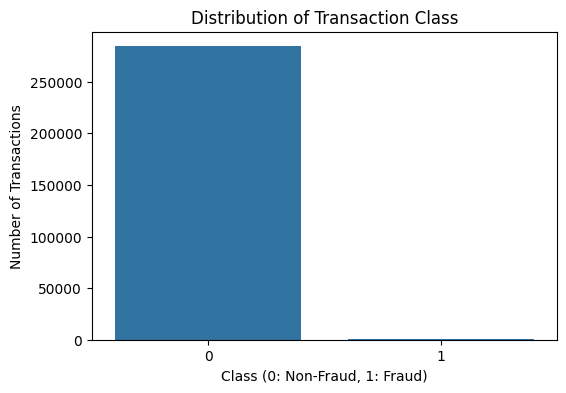

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Transaction Class')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

In [20]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (284807, 30)
Target (y) shape: (284807,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in y_train:")
display(y_train.value_counts(normalize=True) * 100)
print("Class distribution in y_test:")
display(y_test.value_counts(normalize=True) * 100)

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train shape: (227845,)
y_test shape: (56962,)

Class distribution in y_train:


,proportion
Class,
0,99.827075
1,0.172925


Class distribution in y_test:


,proportion
Class,
0,99.827955
1,0.172045


In [22]:
scaler = StandardScaler()

X_train['Time'] = scaler.fit_transform(X_train[['Time']])
X_test['Time'] = scaler.transform(X_test[['Time']])

X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

print("Features 'Time' and 'Amount' have been scaled.")
display(X_train[['Time', 'Amount']].head())

Features 'Time' and 'Amount' have been scaled.


,Time,Amount
265518,1.411588,-0.322494
180305,0.623141,-0.339764
42664,-1.130680,0.346693
198723,0.794699,-0.327360
82325,-0.748102,-0.008281


In [23]:
from imblearn.over_sampling import SMOTE

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original training set class distribution:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nResampled training set shape:", X_train_smote.shape, y_train_smote.shape)
print("Resampled training set class distribution:\n", y_train_smote.value_counts())

print("SMOTE applied successfully to the training data.")

Original training set shape: (227845, 30) (227845,)
Original training set class distribution:
 Class
0    227451
1       394
Name: count, dtype: int64

Resampled training set shape: (454902, 30) (454902,)
Resampled training set class distribution:
 Class
0    227451
1    227451
Name: count, dtype: int64
SMOTE applied successfully to the training data.


In [24]:
import xgboost as xgb

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    n_estimators=100,
    learning_rate=0.1,
    use_label_encoder=False,
    random_state=42
)

print("Training XGBoost model...")
model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully!")

Training XGBoost model...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [06:20:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully!


In [25]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("Retraining XGBoost model without deprecated parameter...")
model.fit(X_train_smote, y_train_smote)

print("XGBoost model retrained successfully!")

Retraining XGBoost model without deprecated parameter...
XGBoost model retrained successfully!


ROC AUC Score on Test Set: 0.9752


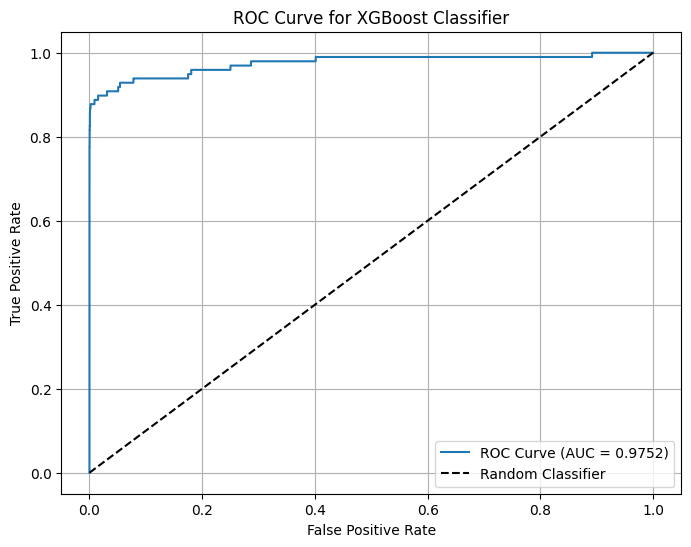


Confusion Matrix (default threshold):


,Predicted 0,Predicted 1
Actual 0,56706,158
Actual 1,12,86



Classification Report (default threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.35      0.88      0.50        98

    accuracy                           1.00     56962
   macro avg       0.68      0.94      0.75     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:
y_pred_proba = model.predict_proba(X_test)[:,1]

y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score on Test Set: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Classifier')
plt.legend()
plt.grid()
plt.show()

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (default threshold):")
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

from sklearn.metrics import classification_report
print("\nClassification Report (default threshold):")
print(classification_report(y_test, y_pred))

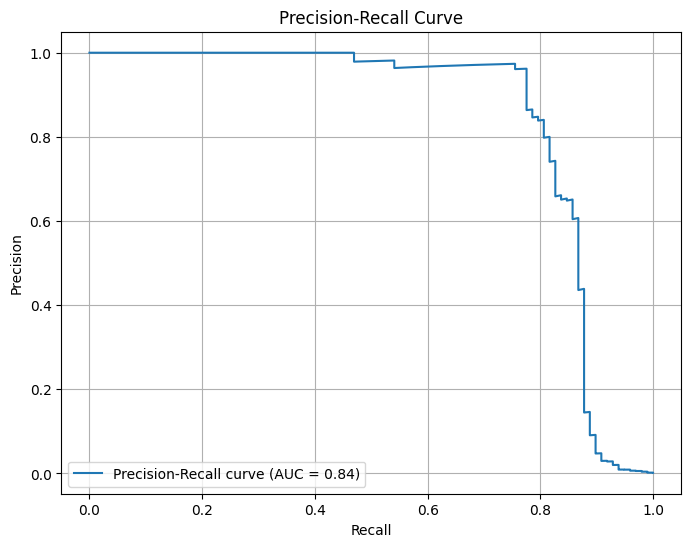


--- Threshold: 0.10 ---
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,55638,1226
Actual 1,10,88


Precision: 0.0670
Recall: 0.8980
F1-Score: 0.1246

--- Threshold: 0.20 ---
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,56256,608
Actual 1,11,87


Precision: 0.1252
Recall: 0.8878
F1-Score: 0.2194

--- Threshold: 0.30 ---
Confusion Matrix:


...

Precision: 0.5944
Recall: 0.8673
F1-Score: 0.7054

--- Threshold: 0.90 ---
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,56831,33
Actual 1,17,81


Precision: 0.7105
Recall: 0.8265
F1-Score: 0.7642

Final Evaluation with Optimal Threshold (0.20):


,Predicted 0,Predicted 1
Actual 0,56256,608
Actual 1,11,87


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.89      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



In [28]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

def evaluate_threshold(y_true, y_pred_proba, threshold):
    y_pred_tuned = (y_pred_proba >= threshold).astype(int)
    cm_tuned = confusion_matrix(y_true, y_pred_tuned)
    tn, fp, fn, tp = cm_tuned.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n--- Threshold: {threshold:.2f} ---")
    print("Confusion Matrix:")
    display(pd.DataFrame(cm_tuned, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

thresholds_to_check = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for t in thresholds_to_check:
    evaluate_threshold(y_test, y_pred_proba, t)

optimal_threshold = 0.2
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(f"\nFinal Evaluation with Optimal Threshold ({optimal_threshold:.2f}):")
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
display(pd.DataFrame(cm_optimal, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))
print(classification_report(y_test, y_pred_optimal))


Top 15 Feature Importances:


,Feature,Importance
14,V14,0.549295
4,V4,0.048124
12,V12,0.042532
8,V8,0.031468
18,V18,0.020741
13,V13,0.018696
26,V26,0.018274
25,V25,0.017523
0,Time,0.016326
29,Amount,0.016274


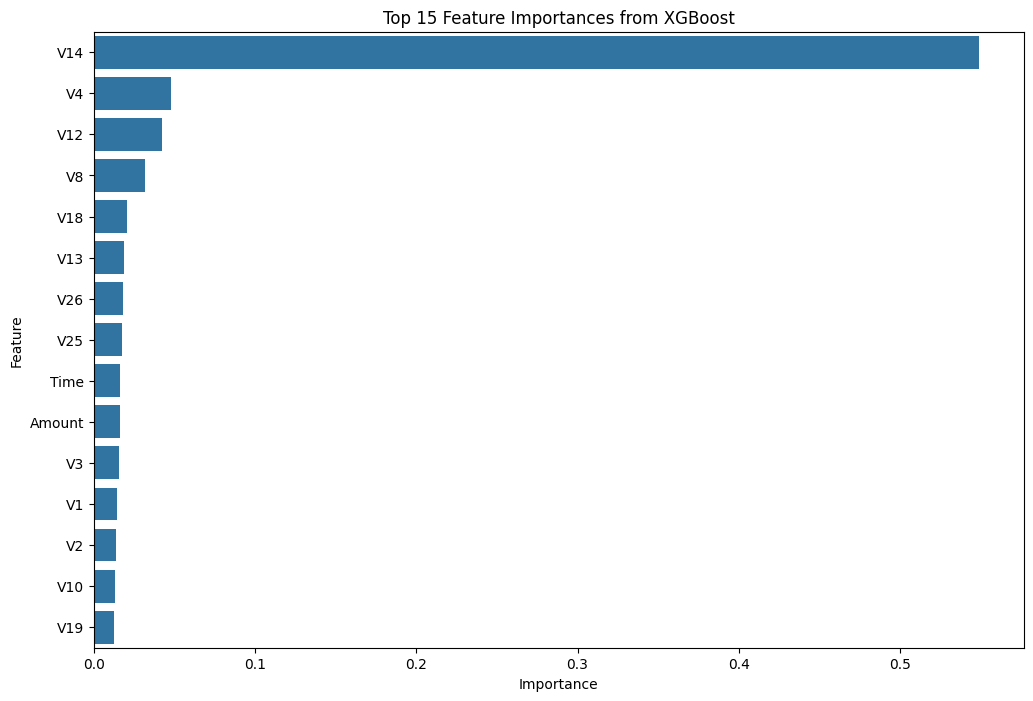

In [29]:
feature_importances = model.feature_importances_

feature_names = X_train_smote.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nTop 15 Feature Importances:")
display(importance_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances from XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()